### **TRABAJO PRÁCTICO N° 2: Redes Convolucionales, Detección de Objetos y Redes Recurrentes - Problema 1**
---
 1er cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
| Martinez Dufour, Caterina | M-7169/2   |
| Grimaldi, Damián Daniel   | G-5977/3   |
| Tapia, Fabrizio           | T-3095/3   |

**Docentes:** *Salvañá, Leandro* - *Fernández, Florencia*

### 1. Descripción del dataset
---

En este ejercicio deben construir, entrenar y optimizar una red neuronal convolucional desde cero (sin transfer learning) para clasificar imágenes de razas de perros. El objetivo es experimentar sistemáticamente con distintas decisiones de diseño arquitectónico y de entrenamiento para maximizar el rendimiento del modelo

#### Variables del conjunto de datos  
**Variables explicativas (features):** 
- Imágenes en formato RGB. Los archivos originales presentan tamaños variables.

**Variable objetivo (target):**  
- Clasificación multiclase para diferenciar entre 70 razas de perro.

#### Librerias

In [ ]:
!pip install gdown

In [52]:
# Librerías
import pandas as pd
import seaborn as sns
import optuna
import gdown
import zipfile
import os
import random, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix

Fijar una semilla aleatoria al inicio de cada experimento para que los resultados sean reproducibles. Esto incluye las semillas de Python, NumPy y el framework de deep learning utilizado:

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del dataset
---

Para comenzar con el desarrollo, cargamos el dataset a través del enlace de Google Drive: "https://drive.google.com/file/d/1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu/view". Descargamos desde el Drive el dataset de los perros en formato zip, lo descomprimimos y lo almacenamos en la carpeta "problema_1/dataset_problema1":

In [5]:
# ID de tu archivo de Drive
file_id = '1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = 'dataset_perros.zip' 

# Descargar el archivo
gdown.download(url, archivo_descargado, quiet=False)
# Descomprimir el archivo en la carpeta
carpeta_destino = 'problema_1/dataset_problema1'

# Creamos la carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraemos el contenido
try:
    with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)
    # Eliminar el archivo .zip descargado
    os.remove(archivo_descargado) 
    
except zipfile.BadZipFile:
    print("Error.")

Downloading...
From (original): https://drive.google.com/uc?id=1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu
From (redirected): https://drive.google.com/uc?id=1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu&confirm=t&uuid=0d6214d1-8224-4ab9-8d77-56ef9dd0fbf8
To: c:\Users\Usuario\cnn-rnn-objectdetection-deeplearning\problema_1\dataset_perros.zip
100%|██████████| 226M/226M [00:37<00:00, 6.09MB/s] 


### 3. Preparación de datos
---

El dataset descargado está dividido en conjuntos de entrenamiento, validación y prueba, cada uno organizado en su respectiva carpeta.

In [6]:
# Definir rutas principales
DATASET_DIR = 'problema_1/dataset_problema1'
CSV_PATH = os.path.join(DATASET_DIR, 'dogs.csv')

df_dogs = pd.read_csv(CSV_PATH)
print("Información del Dataset (dogs.csv):")
print(f"Total de registros anotados: {len(df_dogs)}")

Información del Dataset (dogs.csv):
Total de registros anotados: 9346


A continuación, visualizaremos los datos de entrenamiento mediante un muestreo aleatorio y realizaremos el preprocesamiento de las imágenes:

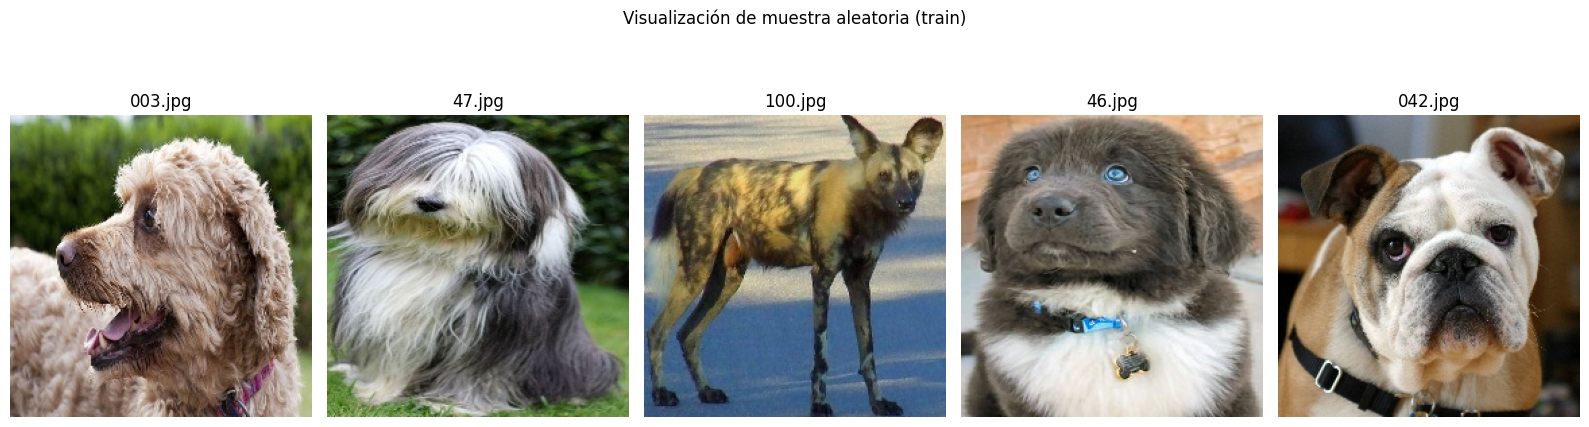

In [7]:
# ruta de dataset de entrenamiento
path_train = os.path.join(DATASET_DIR, 'train')

# lista de las imágenes de entrenamiento
imagenes_train = []
for root, dirs, files in os.walk(path_train):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            imagenes_train.append(os.path.join(root, file))

# Seleccionar 5 imágenes al azar
muestra_fotos = random.sample(imagenes_train, min(5, len(imagenes_train)))
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle('Visualización de muestra aleatoria (train)')

for i, img_path in enumerate(muestra_fotos):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(os.path.basename(img_path))
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Graficamos la distribución de frecuencias para analizar el balance de las clases en el dataset:

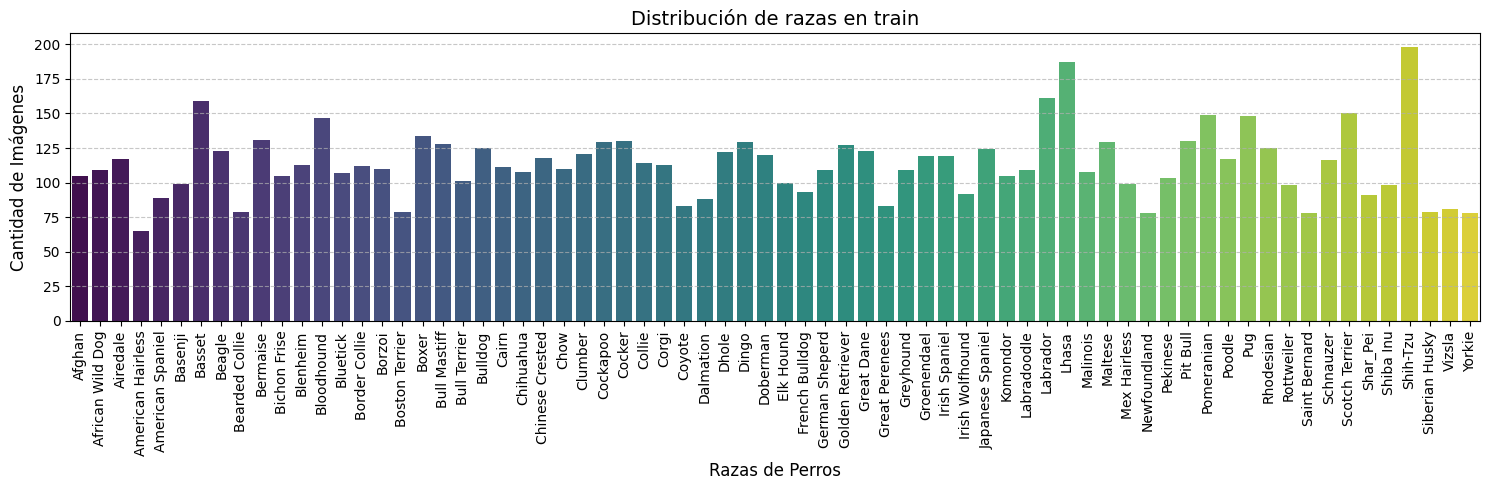

In [8]:
# Extraer el nombre de la raza
razas_train = [os.path.basename(os.path.dirname(p)) for p in imagenes_train]
# Contar cuántas imágenes hay por cada raza
conteo_clases = Counter(razas_train)

plt.figure(figsize=(15, 5))
sns.countplot(x=razas_train, hue=razas_train, palette="viridis", legend=False)
plt.title('Distribución de razas en train', fontsize=14)
plt.xlabel('Razas de Perros', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Al analizar el histograma, observamos un gran desbalance en la cantidad de imágenes, con un rango que oscila entre aproximadamente 65 y 200 imágenes por cada una de las 70 razas de perro. Para evitar que el modelo tenga un sesgo (bias) hacia las clases con más muestras, decidimos normalizar el dataset bajo los siguientes criterios:
- Submuestreo (undersampling): Se limitó a un máximo de 100 imágenes por raza de para mantener un dataset equilibrado y optimizar los tiempos de procesamiento.
- Sobremuestreo sintético: Aquellas razas de perro que tenga menor cantidad de imagenes pasara por un proceso de aumento de datos (data augmentation) para balancear el dataset.

In [9]:
transform_sin_augmentation_train = transforms.Compose([
    # Redimensionar la imagen en 224 x 224
    transforms.Resize((224, 224)),                         
    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),                                 
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_con_augmentation_train = transforms.Compose([
    transforms.Resize((224, 224)),                          # Redimensionar la imagen en 224 x 224
    transforms.RandomHorizontalFlip(p=0.5),                 # Volteo espejo horizontal
    transforms.RandomRotation(degrees=15),                  # Rotación leve
    transforms.ColorJitter(brightness=0.2, contrast=0.2),   # Brillo y contraste

    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### 4. Experimentos
---

Antes de comenzar con la experimentación sistemática, se procedió a definir el diseño modular de la red neuronal convolucional, la estrategia de selección de las clases objetivo y el desarrollo de un bucle de optimización genérico y reutilizable en PyTorch.

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = device 

print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


Dado el alto costo computacional que demanda el entrenamiento de arquitecturas convolucionales complejas desde cero, se implementó un recorte sobre las etiquetas originales del dataset para aislar un subconjunto cerrado de 10 razas de perros:

In [12]:
train_dataset = ImageFolder(root='problema_1/dataset_problema1/train', transform=transform_sin_augmentation_train)
valid_dataset = ImageFolder(root='problema_1/dataset_problema1/valid', transform=transform_sin_augmentation_train)
test_dataset  = ImageFolder(root='problema_1/dataset_problema1/test',  transform=transform_sin_augmentation_train)

NUM_RAZAS = 10
razas_seleccionadas = train_dataset.classes[:NUM_RAZAS]
print(f"Razas seleccionadas: {razas_seleccionadas}\n")

# Buscar los índices de las imágenes que pertenecen a esas 10 razas
# Filtramos basándonos en que la etiqueta sea menor a 10 (0, 1, 2..., 9)
indices_train = [i for i, (_, label) in enumerate(train_dataset) if label < NUM_RAZAS]
indices_valid = [i for i, (_, label) in enumerate(valid_dataset) if label < NUM_RAZAS]
indices_test  = [i for i, (_, label) in enumerate(test_dataset) if label < NUM_RAZAS]

# Crear los subconjuntos recortados
train_dataset = Subset(train_dataset, indices_train)
valid_dataset = Subset(valid_dataset, indices_valid)
test_dataset  = Subset(test_dataset, indices_test)

# Crear los DataLoaders con los datasets ya recortados
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Imágenes de entrenamiento resultantes: {len(train_dataset)}")
print(f"Imágenes de validación resultantes: {len(valid_dataset)}")
print(f"Imágenes de test resultantes: {len(test_dataset)}")

Razas seleccionadas: ['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise']

Imágenes de entrenamiento resultantes: 1076
Imágenes de validación resultantes: 100
Imágenes de test resultantes: 100


#### Función de la red convolucional

Se diseñó un constructor genérico basado en los siguientes componentes de diseño:
- Estructura de Bloques Convolucionales: Cada bloque operativo encapsula de manera secuencial dos capas de convolución (nn.Conv2d) con filtros de tamaño 3x3 y relleno (padding) adaptativo.
- Normalización por Lotes: Estabiliza la distribución de las activaciones en las capas intermedias.
- Pooling Adaptativo Global: Esta función calcula el promedio de cada canal reduciendo la resolución espacial a un tamaño fijo de 1x1. 

In [10]:
class CNN_Generica(nn.Module):
    def __init__(self, num_clases, config_bloques, dropout_rate=0.5, kernel_size=3):
        """
        num_clases: Número de razas de perros (10).
        config_bloques: Lista de tuplas con la estructura [(canales_in, canales_out), ...]
                        Ej para E1: [(3, 32), (32, 64), (64, 128)]
        dropout_rate: Fracción de neuronas para el Dropout.
        kernel_size: Tamaño del filtro (3 para 3x3, 5 para 5x5).
        """
        super().__init__()  # llama al constructor de la clase padre nn.Module.
        
        # El padding se calcula automáticamente para mantener las dimensiones espaciales antes del MaxPool
        padding = kernel_size // 2 
        
        # Construcción de la etapa convolucional
        bloques = []
        for i, (in_ch, out_ch) in enumerate(config_bloques):
            bloque = nn.Sequential(
                # padding: agrega 1 fila/columna de ceros en cada borde.
                # bias=False: no se aprende un bias por neurona.
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding, bias=False),
                # normalización de batch para feature maps.
                nn.BatchNorm2d(out_ch), 
                # inplace=True: modifica el tensor en el lugar sin crear una copia.
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=kernel_size, padding=padding, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                # kernel_size=2: ventana 2×2 píxeles. stride=2: el paso entre posiciones de la ventana es 2.
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
            bloques.append(bloque)
            
        # Almacena los bloques en un ModuleList para que PyTorch registre correctamente sus parámetros
        self.etapa_convolucional = nn.ModuleList(bloques)
        
        # Capa de pooling adaptativo
        # Fuerza a que el mapa de características final mida 1x1 en su resolución espacial.
        self.pool_global = nn.AdaptiveAvgPool2d((1, 1))
        
        # El número de canales que recibe la capa lineal es simplemente el 'out_ch' del último bloque
        ultimo_canal_salida = config_bloques[-1][1]
        
        # Clasificador denso 
        # Convierte los feature maps en una predicción escalar (logit).
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(ultimo_canal_salida, 256), 
            # ReLU después de la capa densa: introduce no-linealidad.
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_clases),
        )
        
        self._init_pesos()      # Inicializar los pesos de todas las capas.

    def _init_pesos(self):
        """
        Inicializa los pesos de todas las capas del modelo.

        self.modules(): iterador recursivo que devuelve TODOS los submódulos
        del modelo, incluyendo los anidados dentro de nn.Sequential.

        isinstance(m, nn.Conv2d): True solo si m es una capa Conv2d.
        Usamos isinstance en vez de type(m) == nn.Conv2d para ser correcto
        con herencia: si algún submódulo hereda de Conv2d, también aplica.
        """
        for m in self.modules():
            # Inicialización Kaiming Normal (He initialization) para Conv2d
            if isinstance(m, nn.Conv2d):
                # mode='fan_out': usa el número de conexiones de SALIDA para calcular la varianza
                # nonlinearity='relu': ajusta la constante de escala para ReLU.
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                # BatchNorm2d tiene dos parámetros aprendibles: γ (weight) y β (bias)
                nn.init.ones_(m.weight)         # γ ← 1 para todos los canales (estandar)
                nn.init.zeros_(m.bias)          # β ← 0 para todos los canales (estandar)
            elif isinstance(m, nn.Linear):
                # El bias de Linear lo inicializamos en cero
                # El entrenamiento lo ajustará al valor que necesite
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        Define el flujo de datos a través de la red.
        PyTorch llama a este método automáticamente cuando hacemos modelo(x).

        x: tensor de entrada con forma (batch_size, 3, 224, 224).
        """
        # Pasa dinámicamente por todos los bloques definidos
        for bloque in self.etapa_convolucional:
            x = bloque(x)
            
        x = self.pool_global(x)  # Reduce a (batch, ultimo_canal, 1, 1)
        x = self.clasificador(x) # aplana y clasifica
        return x

#### Función de entrenamiento de la red convolucional

In [ ]:
def loop_entrenamiento_cnn(modelo, loader_train, loader_val, criterio, optimizador, scheduler, epochs=50, patience=10, device=DEVICE, nombre='CNN'):
    """
    Loop de entrenamiento genérico para CNNs en PyTorch.
    Reutilizable para clasificación binaria y multiclase.

    Parámetros:
        modelo:       instancia de nn.Module ya creada y movida al dispositivo.
        loader_train: DataLoader con el conjunto de entrenamiento.
        loader_val:   DataLoader con el conjunto de validación.
        criterio:     función de pérdida (BCEWithLogitsLoss o CrossEntropyLoss).
        optimizador:  algoritmo de optimización (Adam, SGD, etc.).
        scheduler:    ajustador de learning rate (ReduceLROnPlateau).
        epochs:       número máximo de épocas a entrenar.
        patience:     épocas sin mejora en val_loss antes de hacer early stopping.
        device:       dispositivo donde están el modelo y los datos.
        nombre:       string para identificar el modelo en los mensajes.
    """

    # historial: diccionario donde guardamos las métricas de cada época.
    historial = {
        'train_loss': [],   # pérdida promedio en el training set por época
        'val_loss':   [],   # pérdida promedio en el validation set por época
        'train_acc':  [],   # accuracy en training por época
        'val_acc':    [],   # accuracy en validation por época
    }

    # mejor_val_loss: la menor pérdida de validación vista hasta ahora.
    mejor_val_loss = float('inf')

    # mejor_pesos: copia del state_dict del modelo en el momento de menor val_loss.
    # state_dict es un diccionario {nombre_capa: tensor_de_pesos}.
    mejor_pesos = None

    # espera: contador de épocas consecutivas sin mejora en val_loss.
    # Cuando llega a 'patience', se activa el early stopping.
    espera = 0

    print(f"\n Entrenando {nombre} | epochs={epochs} | patience={patience}")
    print(f"   {'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Train Acc':>10} | {'Val Acc':>9} | {'LR':>8}")
    print("   " + "─"*62)

    for epoca in range(1, epochs + 1):

        # ════════════════════════════════════════════════════════
        #  FASE DE ENTRENAMIENTO
        # ════════════════════════════════════════════════════════

        # modelo.train(): pone el modelo en modo entrenamiento.
        # Activa dos comportamientos que son distintos en training vs inferencia:
        #   1. Dropout: apaga neuronas aleatoriamente (en eval lo desactiva).
        #   2. BatchNorm: usa estadísticas del batch actual Y actualiza running_mean y running_var (en eval usa solo los acumulados).
        modelo.train()

        # Acumuladores para calcular el promedio al final de la época.
        train_loss_total = 0.0   # suma de (loss × tamaño_batch) de todos los batches
        train_correctos  = 0     # total de predicciones correctas en la época
        train_total      = 0     # total de ejemplos procesados en la época

        for X_batch, y_batch in loader_train:
            # loader_train es un iterador: en cada iteración devuelve un par
            # (X_batch, y_batch) donde:
            #   X_batch: tensor de imágenes, forma (batch_size, 3, 32, 32)
            #   y_batch: tensor de etiquetas, forma (batch_size,)

            # .to(device): mueve X_batch e y_batch al mismo dispositivo que el modelo.
            # Si el modelo está en GPU y los datos en CPU, PyTorch da error.
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Conversión de tipo para BCEWithLogitsLoss:
            # Los DataLoaders de torchvision devuelven etiquetas como torch.int64 (long).
            # BCEWithLogitsLoss requiere float32 porque opera con probabilidades continuas.
            # CrossEntropyLoss sí acepta long, por eso solo convertimos para BCE.
            if isinstance(criterio, nn.BCEWithLogitsLoss):
                # .float(): convierte de int64 a float32.
                # {0, 1} enteros → {0.0, 1.0} flotantes.
                y_batch = y_batch.float()

            # ── FORWARD PASS ────────────────────────────────────
            # logits: tensor de forma (batch_size,) para binaria o (batch_size, N) para multiclase.
            # No tienen activación: son números reales arbitrarios en (-∞, +∞).
            logits = modelo(X_batch)

            # criterio(logits, y_batch): calcula la pérdida del batch.
            # Para BCEWithLogitsLoss: aplica Sigmoid a los logits y calcula BCE.
            # Para CrossEntropyLoss: aplica Softmax a los logits y calcula CCE.
            # loss es un escalar (tensor de forma ()).
            loss = criterio(logits, y_batch)

            # ── BACKWARD PASS ───────────────────────────────────
            # optimizador.zero_grad(): limpia los gradientes acumulados del paso anterior.
            # PyTorch acumula gradientes por defecto (diseñado para RNNs/TBPTT).
            optimizador.zero_grad()

            # loss.backward(): calcula ∂L/∂w para TODOS los parámetros del modelo.
            # Recorre el grafo computacional hacia atrás (output → input) aplicando la Regla de la Cadena. Al terminar, cada parámetro p tiene p.grad = ∂L/∂p.
            loss.backward()

            # Gradient clipping: limita la norma euclidiana del gradiente total.
            # clip_grad_norm_(parámetros, max_norm=1.0):
            #   Calcula la norma del gradiente: ||∇|| = √(Σ (∂L/∂w_i)²)
            #   Si ||∇|| > max_norm: escala todos los gradientes por max_norm/||∇||
            #   Si ||∇|| ≤ max_norm: no hace nada.
            # max_norm=1.0: si la norma del gradiente supera 1.0, se recorta.
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)

            # optimizador.step(): actualiza los pesos usando los gradientes calculados.
            optimizador.step()

            # Acumular pérdida ponderada por el tamaño del batch.
            # loss.item(): extrae el valor escalar del tensor (Python float).
            train_loss_total += loss.item() * X_batch.size(0)

            # Calcular predicciones y contar aciertos del batch.
            if isinstance(criterio, nn.MSELoss):
                pass   # no hay accuracy en regresión
            elif isinstance(criterio, nn.BCEWithLogitsLoss):
                preds = (torch.sigmoid(logits) > 0.5).long()
                train_correctos += (preds == y_batch.long()).sum().item()
            else:
                preds = logits.argmax(dim=1)
                train_correctos += (preds == y_batch).sum().item()

            train_total += X_batch.size(0)

        train_loss = train_loss_total / train_total
        train_acc  = train_correctos  / train_total

        # ════════════════════════════════════════════════════════
        #  FASE DE VALIDACIÓN (sin actualizar pesos)
        # ════════════════════════════════════════════════════════

        # modelo.eval(): pone el modelo en modo inferencia.
        # Desactiva Dropout: todas las neuronas activas, predicciones determinísticas.
        # BatchNorm: usa running_mean y running_var acumulados, no las del batch actual.
        modelo.eval()
        val_loss_total = 0.0
        val_correctos  = 0
        val_total      = 0

        # torch.no_grad(): bloque de contexto que desactiva el cálculo del grafo.
        with torch.no_grad():
            for X_val, y_val in loader_val:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                logits_v = modelo(X_val)
                if isinstance(criterio, nn.MSELoss):
                    loss_v = criterio(logits_v, y_val)
                elif isinstance(criterio, nn.BCEWithLogitsLoss):
                    y_val_f = y_val.float()
                    loss_v  = criterio(logits_v, y_val_f)
                    preds_v = (torch.sigmoid(logits_v) > 0.5).long()
                    val_correctos += (preds_v == y_val).sum().item()
                else:
                    loss_v  = criterio(logits_v, y_val)
                    preds_v = logits_v.argmax(dim=1)
                    val_correctos += (preds_v == y_val).sum().item()
                # Estas dos líneas estaban faltando:
                val_loss_total += loss_v.item() * X_val.size(0)
                val_total      += X_val.size(0)

        val_loss = val_loss_total / val_total
        val_acc  = val_correctos  / val_total

        # Guardar métricas de esta época en el historial
        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['train_acc'].append(train_acc)
        historial['val_acc'].append(val_acc)

        # ── SCHEDULER ───────────────────────────────────────────
        # optimizador.param_groups[0]['lr']: extrae el learning rate actual.
        # param_groups es una lista de diccionarios, uno por grupo de parámetros.
        # Con un solo grupo (el default), el índice [0] es el único grupo.
        # Guardamos el lr ANTES de llamar scheduler.step() porque el scheduler
        # puede modificarlo, y queremos imprimir el lr que se usó en esta época.
        lr_actual = optimizador.param_groups[0]['lr']

        # scheduler.step(val_loss): informa al scheduler la pérdida de validación.
        # ReduceLROnPlateau compara val_loss con su mejor valor histórico:
        #   Si no mejoró durante 'patience' épocas → lr ← lr × factor (0.5).
        #   Si mejoró → reinicia el contador.
        # Esto hace que el learning rate baje cuando el entrenamiento se estanca,
        # permitiendo una búsqueda más fina en la vecindad del mínimo actual.
        scheduler.step(val_loss)

        # ── EARLY STOPPING ──────────────────────────────────────
        if val_loss < mejor_val_loss:
            # Nueva mejor val_loss: guardar el estado actual del modelo.
            mejor_val_loss = val_loss
            # modelo.state_dict(): diccionario {nombre_parámetro: tensor_de_pesos}.
            # Contiene TODOS los parámetros y buffers (running_mean de BatchNorm, etc.).
            # {k: v.clone()}: hacemos una COPIA PROFUNDA de cada tensor.
            # Sin .clone(), el diccionario guardaría referencias a los mismos tensores
            # en memoria, que seguirán cambiando en las épocas siguientes.
            # Con .clone(), guardamos el estado exacto de este momento.
            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            espera = 0   # reiniciar contador de épocas sin mejora
        else:
            espera += 1  # una época más sin mejorar

        # Imprimir progreso cada 5 épocas o cuando hay una mejora (espera==0)
        if epoca % 5 == 0 or espera == 0:
            if isinstance(criterio, nn.MSELoss):
                print(f"   {epoca:6d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                      f"  RMSE val={val_loss**0.5:.4f} | {lr_actual:.2e}")
            else:
                print(f"   {epoca:6d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                      f"{train_acc:10.4f} | {val_acc:9.4f} | {lr_actual:.2e}")

        # Condición de parada anticipada
        if espera >= patience:
            print(f"\n Early stopping en época {epoca} "
                  f"(mejor val_loss: {mejor_val_loss:.4f})")
            break

    # Restaurar los pesos del mejor momento del entrenamiento.
    # load_state_dict(mejor_pesos): carga el diccionario guardado en el modelo.
    # strict=True (default): los nombres de las capas deben coincidir exactamente.
    if mejor_pesos:
        modelo.load_state_dict(mejor_pesos)
        print(f"Mejores pesos restaurados (época con menor val_loss)")

    return historial

#### Función para evaluar test

In [ ]:
def evaluar_precision_test(modelo, loader_test, device):
    modelo.eval() # Modo evaluación
    correctas = 0
    total = 0
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes
        for X_batch, y_batch in loader_test:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = modelo(X_batch)
            preds = logits.argmax(dim=1)
            
            correctas += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            
    return (correctas / total) * 100

#### E1 — Línea base

El objetivo de este primer experimento es establecer una línea base utilizando una configuración convolucional estándar:
- Se instanció la estructura CNN_Generica parametrizada con 3 bloques convolucionales progresivos y filtros estáticos de 3x3.
- Gracias a la incorporación de la capa de Pooling Adaptativo Global, el modelo base cuenta únicamente con 323.050 parámetros entrenables.
- El entrenamiento se configuró con una tasa de aprendizaje de 0.0001 administrada con el optimizador Adam y una política de reducción dinámica ReduceLROnPlateau fijada con una paciencia de 3 épocas. 

In [14]:
NUM_RAZAS = 10
# Crear el modelo
config_e1 = [(3, 32), (32, 64), (64, 128)]
model_e1 = CNN_Generica(num_clases=10, config_bloques=config_e1, kernel_size=3).to(DEVICE)

# Configuramos su optimizador y su scheduler
criterion = nn.CrossEntropyLoss()
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=0.0001)
scheduler_e1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_e1, mode='min', factor=0.5, patience=3)

# llamamos a la función y guardamos el resultado en "historial_e1"
historial_e1 = loop_entrenamiento_cnn(
    modelo=model_e1,
    loader_train=train_loader,
    loader_val=valid_loader,
    criterio=criterion,
    optimizador=optimizer_e1,
    scheduler=scheduler_e1,
    epochs=15,             # Las 15 épocas que definimos para la línea base
    patience=5,            # Si pasa 5 épocas sin mejorar el loss de val, frena solo
    device=DEVICE,
    nombre='E1_LineaBase'
)


 Entrenando E1_LineaBase | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.5464 |     2.2451 |     0.1608 |    0.1900 | 1.00e-04
        2 |     2.2314 |     2.1805 |     0.2175 |    0.2500 | 1.00e-04
        3 |     2.0635 |     2.0877 |     0.2686 |    0.3300 | 1.00e-04
        4 |     1.9693 |     2.0813 |     0.3011 |    0.3200 | 1.00e-04
        5 |     1.8725 |     2.0507 |     0.3494 |    0.3200 | 1.00e-04
        6 |     1.8532 |     2.0322 |     0.3643 |    0.3000 | 1.00e-04
        8 |     1.7704 |     1.9951 |     0.3801 |    0.3400 | 1.00e-04
        9 |     1.7294 |     1.9844 |     0.3903 |    0.3800 | 1.00e-04
       10 |     1.6879 |     2.0830 |     0.4229 |    0.3100 | 1.00e-04
       13 |     1.5834 |     1.9579 |     0.4712 |    0.3600 | 1.00e-04
       14 |     1.5678 |     1.9513 |     0.4498 |    0.3800 | 1.00e-04
       15 |     1.4

Al observar los resultados, podemos decir que el error en el conjunto de entrenamiento fue disminuyendo progresivamente hasta alcanzar una pérdida de 1.4929, logrando un accuracy (exactitud) del 50%. Por su parte, el conjunto de validación alcanzó en su mejor punto una pérdida de 1.8912, consolidando una exactitud final del 40%.

In [33]:
total_p_e1 = sum(p.numel() for p in model_e1.parameters())
print(f"Total parámetros E1: {total_p_e1:,}")

Total parámetros E1: 323,050


In [79]:
acc_test_e1 = evaluar_precision_test(model_e1, test_loader, DEVICE)
print(f"E1 - Accuracy en Test: {acc_test_e1:.2f}%")

E1 - Accuracy en Test: 58.00%


#### E2 — Arquitectura más profunda

El objetivo de este segundo experimento consiste en evaluar el impacto de incrementar la complejidad del modelo añadiendo mayor profundidad a la etapa de extracción de características, manteniendo fijos el tamaño del kernel en 3x3 y los hiperparámetros de optimización de la línea base.
- Se extendió la estructura convolucional agregando un cuarto bloque operativo jerárquico, duplicando el techo máximo de canales de salida a 256.
- Al añadir convoluciones más pesadas en el bloque profundo, el modelo experimentó un salto considerable en su tamaño, alcanzando un total de 1,241,578 parámetros entrenables.
- Se mantuvo el optimizador Adam con una tasa de aprendizaje inicial de 0.0001 con paciencia de 3 épocas y un entrenamiento de 15 épocas.

In [15]:
NUM_RAZAS = 10
# Crear el modelo
config_e2 = [(3, 32), (32, 64), (64, 128), (128, 256)]
model_e2 = CNN_Generica(num_clases=10, config_bloques=config_e2, kernel_size=3).to(DEVICE)

# Configuramos su optimizador y su scheduler obligatorio
criterion = nn.CrossEntropyLoss()
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=0.0001)
scheduler_e2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_e2, mode='min', factor=0.5, patience=3)

# LLAMAMOS A LA FUNCIÓN GENÉRICA Y GUARDAMOS EL HISTORIAL EN 'historial_e2'
historial_e2 = loop_entrenamiento_cnn(
    modelo=model_e2,
    loader_train=train_loader,
    loader_val=valid_loader,
    criterio=criterion,
    optimizador=optimizer_e2,
    scheduler=scheduler_e2,
    epochs=15,             # Las 15 épocas que definimos para la línea base
    patience=5,            # Si pasa 5 épocas sin mejorar el loss de val, frena solo
    device=DEVICE,
    nombre='E2_MasProfunda'
)


 Entrenando E2_MasProfunda | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.4038 |     2.1936 |     0.1803 |    0.3300 | 1.00e-04
        2 |     1.9523 |     2.0556 |     0.3225 |    0.3600 | 1.00e-04
        3 |     1.7387 |     2.0214 |     0.3820 |    0.3600 | 1.00e-04
        4 |     1.6345 |     1.8963 |     0.4470 |    0.4000 | 1.00e-04
        5 |     1.5370 |     1.8760 |     0.4777 |    0.4100 | 1.00e-04
        6 |     1.4153 |     1.8749 |     0.5260 |    0.4200 | 1.00e-04
        7 |     1.3537 |     1.8130 |     0.5400 |    0.4400 | 1.00e-04
        8 |     1.2687 |     1.7844 |     0.5641 |    0.4700 | 1.00e-04
       10 |     1.1558 |     1.7417 |     0.6087 |    0.5000 | 1.00e-04
       11 |     1.1331 |     1.6962 |     0.6041 |    0.5000 | 1.00e-04
       13 |     1.0550 |     1.6344 |     0.6348 |    0.5300 | 1.00e-04
       15 |     0

Al observar los resultados, podemos decir que el error en el conjunto de entrenamiento fue disminuyendo de manera constante y pronunciada a lo largo de las épocas hasta alcanzar una pérdida mínima de 0.9357, logrando un accuracy (exactitud) del 70.45% en la época 15. Por su parte, el conjunto de validación en la época 15, el error de validación volvió a subir a 1.7204 y la exactitud cayó al 49.00% de la época 13.

In [ ]:
total_p_e2 = sum(p.numel() for p in model_e2.parameters())
print(f"Total parámetros E2: {total_p_e2:,}")

Total parámetros E2: 1,241,578


In [80]:
acc_test_e2 = evaluar_precision_test(model_e2, test_loader, DEVICE)
print(f"E2 - Accuracy en Test: {acc_test_e2:.2f}%")

E2 - Accuracy en Test: 69.00%


#### E3 — Bloques avanzados

El objetivo de este tercer experimento es evaluar la incorporación de conceptos arquitectónicos avanzados inspirados en la topología ResNet. Se introdujeron conexiones de salto o atajos (skip connections) para permitir el flujo directo de gradientes y evaluar si esta flexibilidad estructural mejora el aprendizaje respecto a las redes puramente secuenciales.

- Se diseñó una estructura específica que reemplaza los bloques básicos por objetos modulares independientes denominados BloqueResidual. Cada uno de ellos procesa la entrada a través de dos convoluciones de 3x3 pero suma el tensor de identidad original al mapa final antes de la activación de salida.
- Al emplear bloques residuales eficientes y conservar el Pooling Adaptativo Global, el modelo final requiere únicamente 342.954 parámetros entrenables.
- Se mantuvieron estables todas las condiciones de los entrenamientos anteriores.

In [ ]:
# Definimos el bloque residual nativo con su skip connection
class BloqueResidual(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        
        # Si cambian los canales, adaptamos el tamaño del atajo
        self.shortcut = nn.Sequential()
        if in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity  # 🪄 Conexión de salto
        return self.relu(out)

# Creamos una mini arquitectura que use este bloque heredando de nn.Module
class CNN_Experimento3(nn.Module):
    def __init__(self, num_clases, dropout_rate=0.5):
        super().__init__()
        self.pre_capa = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        # Reutilizamos los bloques residuales alternando con MaxPool
        self.b1 = BloqueResidual(32, 32)
        self.p1 = nn.MaxPool2d(2, 2)
        self.b2 = BloqueResidual(32, 64)
        self.p2 = nn.MaxPool2d(2, 2)
        self.b3 = BloqueResidual(64, 128)
        self.p3 = nn.MaxPool2d(2, 2)
        
        self.pool_global = nn.AdaptiveAvgPool2d((1, 1))
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_clases)
        )
        
    def forward(self, x):
        x = self.p1(self.b1(self.pre_capa(x)))
        x = self.p2(self.b2(x))
        x = self.p3(self.b3(x))
        return self.clasificador(self.pool_global(x))

In [20]:
NUM_RAZAS = 10

# Crear el modelo
model_e3 = CNN_Experimento3(num_clases=NUM_RAZAS, dropout_rate=0.5).to(DEVICE)

# Configuramos su optimizador y su scheduler obligatorio
criterion = nn.CrossEntropyLoss()
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=0.0001)
scheduler_e3 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_e3, mode='min', factor=0.5, patience=3)

# LLAMAMOS A LA FUNCIÓN GENÉRICA Y GUARDAMOS EL HISTORIAL EN 'historial_e3'
historial_e3 = loop_entrenamiento_cnn(
    modelo=model_e3,
    loader_train=train_loader,
    loader_val=valid_loader,
    criterio=criterion,
    optimizador=optimizer_e3,
    scheduler=scheduler_e3,
    epochs=15,             # Las 15 épocas que definimos para la línea base
    patience=5,            # Si pasa 5 épocas sin mejorar el loss de val, frena solo
    device=DEVICE,
    nombre='E3_ConSkipConnections'
)


 Entrenando E3_ConSkipConnections | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.2517 |     2.2577 |     0.1729 |    0.1300 | 1.00e-04
        2 |     2.1022 |     2.1507 |     0.2481 |    0.2400 | 1.00e-04
        3 |     2.0313 |     2.0875 |     0.2862 |    0.2100 | 1.00e-04
        4 |     1.9337 |     2.0201 |     0.3383 |    0.3600 | 1.00e-04
        5 |     1.8832 |     2.0119 |     0.3708 |    0.2900 | 1.00e-04
        6 |     1.8357 |     1.9376 |     0.3838 |    0.3600 | 1.00e-04
        7 |     1.7894 |     1.9333 |     0.3903 |    0.3500 | 1.00e-04
        8 |     1.7450 |     1.8649 |     0.4145 |    0.3900 | 1.00e-04
       10 |     1.6690 |     1.9061 |     0.4480 |    0.3600 | 1.00e-04
       11 |     1.6475 |     1.8346 |     0.4489 |    0.3800 | 1.00e-04
       15 |     1.5197 |     1.8522 |     0.5074 |    0.3700 | 1.00e-04
Mejores pe

Al observar los resultados, podemos decir que el error en el conjunto de entrenamiento disminuyó de manera progresiva y regular época a época hasta alcanzar una pérdida de 1.5197, logrando un accuracy (exactitud) del 50.74% en la época 15. Por su parte, el conjunto de validación alcanzó su mejor desempeño en la época 11, consolidando una pérdida mínima de 1.8346 y una exactitud asociada del 38.00%, cerrando la última época con un 37.00% de exactitud.

In [34]:
total_p_e3 = sum(p.numel() for p in model_e3.parameters())
print(f"Total parámetros E3: {total_p_e3:,}")

Total parámetros E3: 342,954


In [81]:
acc_test_e3 = evaluar_precision_test(model_e3, test_loader, DEVICE)
print(f"E3 - Accuracy en Test: {acc_test_e3:.2f}%")

E3 - Accuracy en Test: 49.00%


#### E4 — Regularización y Data Augmentation

El objetivo de este último experimento es incorporar técnicas de regularización directa a través de un pipeline de Data Augmentation y la búsqueda inteligente de hiperparámetros asistida por optimización bayesiana.

In [26]:
train_dataset_aug = ImageFolder(root='problema_1/dataset_problema1/train', transform=transform_con_augmentation_train)

# Crear los subconjuntos recortados
train_subset_e4 = Subset(train_dataset_aug, indices_train)  
valid_subset_e4 = Subset(valid_dataset, indices_valid)      

# Crear los DataLoaders con los datasets ya recortados
train_loader_e4 = DataLoader(train_subset_e4, batch_size=32, shuffle=True, num_workers=2)
valid_loader_e4 = DataLoader(valid_subset_e4, batch_size=32, shuffle=False, num_workers=2)

##### Optimización Bayesiana

Optimizamos los siguientes hiperparámetros para evaluar con optuna:
- Learning Rate: Evaluada en el espacio de búsqueda [0.0001, 0.001, 0.01].
- Dropout: Evaluada en el rango [0.1, 0.2, 0.3, 0.4].
- Cada prueba (trial) se entrenó durante 5 épocas utilizando como métrica guía la maximización de la exactitud en el conjunto de validación (val_acc). 

In [24]:
def objective(trial):
    lr = trial.suggest_categorical('learning_rate', [0.0001, 0.001, 0.01])
    dropout_p = trial.suggest_categorical('dropout', [0.1, 0.2, 0.3, 0.4])
    
    # Creamos el modelo
    model = CNN_Experimento3(num_clases=10, dropout_rate=dropout_p).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    # 4. LANZAR TU LOOP GENÉRICO INTACTO 
    historial = loop_entrenamiento_cnn(
        modelo=model,
        loader_train=train_loader_e4,   # Tu loader con Data Augmentation (creado arriba)
        loader_val=valid_loader_e4,     # Validación limpia sin alteraciones
        criterio=criterion,
        optimizador=optimizer,
        scheduler=scheduler,
        epochs=5,                       # Suficiente para ver la tendencia de mejora
        patience=2,
        device=DEVICE,
        nombre='Optuna_E4_Trial'
    )
    
    # Utilizamos la metrica de Accuracy en validacion
    val_score = max(historial['val_acc'])
    return val_score

In [27]:
# Creamos el estudio indicando que busque el máximo Accuracy
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=8)

print(f"Mejores hiperparámetros: {study.best_params}")

[I 2026-05-24 17:48:50,943] A new study created in memory with name: no-name-62259e78-7225-4745-bf1b-a0bc2999af08



 Entrenando Optuna_E4_Trial | epochs=5 | patience=2
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.3031 |     2.3960 |     0.1608 |    0.1500 | 1.00e-02
        2 |     2.1340 |     2.2976 |     0.2091 |    0.2300 | 1.00e-02
        4 |     2.0063 |     2.1898 |     0.2770 |    0.3100 | 1.00e-02


[I 2026-05-24 18:04:22,938] Trial 0 finished with value: 0.31 and parameters: {'learning_rate': 0.01, 'dropout': 0.1}. Best is trial 0 with value: 0.31.


        5 |     1.9752 |     2.1534 |     0.2993 |    0.2700 | 1.00e-02
Mejores pesos restaurados (época con menor val_loss)

 Entrenando Optuna_E4_Trial | epochs=5 | patience=2
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.2469 |     2.3103 |     0.1803 |    0.1800 | 1.00e-02
        2 |     2.0668 |     2.1376 |     0.2528 |    0.2600 | 1.00e-02
        3 |     1.9952 |     2.0591 |     0.2844 |    0.3200 | 1.00e-02


[I 2026-05-24 18:19:56,371] Trial 1 finished with value: 0.36 and parameters: {'learning_rate': 0.01, 'dropout': 0.1}. Best is trial 1 with value: 0.36.


...

        5 |     1.7349 |     1.9544 |     0.3810 |    0.3300 | 1.00e-03
Mejores pesos restaurados (época con menor val_loss)

 Entrenando Optuna_E4_Trial | epochs=5 | patience=2
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.2217 |     2.1867 |     0.1989 |    0.2200 | 1.00e-02
        2 |     2.0479 |     2.0768 |     0.2565 |    0.3300 | 1.00e-02


[I 2026-05-24 19:22:22,814] Trial 6 finished with value: 0.33 and parameters: {'learning_rate': 0.01, 'dropout': 0.1}. Best is trial 5 with value: 0.38.



 Early stopping en época 4 (mejor val_loss: 2.0768)
Mejores pesos restaurados (época con menor val_loss)

 Entrenando Optuna_E4_Trial | epochs=5 | patience=2
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.3080 |     2.7925 |     0.1561 |    0.1200 | 1.00e-02
        2 |     2.1152 |     2.3154 |     0.2091 |    0.2200 | 1.00e-02
        3 |     2.0866 |     2.1368 |     0.2240 |    0.3300 | 1.00e-02
        4 |     2.0474 |     2.0158 |     0.2398 |    0.2100 | 1.00e-02


[I 2026-05-24 19:36:05,557] Trial 7 finished with value: 0.33 and parameters: {'learning_rate': 0.01, 'dropout': 0.3}. Best is trial 5 with value: 0.38.


        5 |     1.9743 |     2.1468 |     0.2695 |    0.2200 | 1.00e-02
Mejores pesos restaurados (época con menor val_loss)
Mejores hiperparámetros: {'learning_rate': 0.001, 'dropout': 0.4}


Luego de ejecutar la optimización bayesiana con 8 iteraciones, los mejores hiperparámetros encontrados fueron: 
- Una tasa de aprendizaje de 0.001 
- Un dropout de 0.4

##### Experimento 4 con hiperparametros de optuna

- El conjunto de entrenamiento se le aplicó data augmentation.
- El conjunto de validación se mantuvo completamente limpio y sin alteraciones. 
- Se utilizó la base profunda de 4 bloques convolucionales (config_e4), integrando la tasa de desecho densa de 0.4 dado por Optuna. 
-El modelo cuenta con 1,241,578 parámetros entrenables.

In [ ]:
NUM_RAZAS = 10

# Crear el modelo
config_e4 = [(3, 32), (32, 64), (64, 128), (128, 256)]
model_e4 = CNN_Generica(num_clases=NUM_RAZAS, config_bloques=config_e4, kernel_size=3, dropout_rate=0.4).to(DEVICE)

# Configuramos su optimizador y su scheduler obligatorio
criterion = nn.CrossEntropyLoss()
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=0.001)
scheduler_e4 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_e4, mode='min', factor=0.5, patience=3)

# LLAMAMOS A LA FUNCIÓN GENÉRICA Y GUARDAMOS EL HISTORIAL EN 'historial_e4'
historial_e4 = loop_entrenamiento_cnn(
    modelo=model_e4,
    loader_train=train_loader_e4, 
    loader_val=valid_loader_e4,   
    criterio=criterion,
    optimizador=optimizer_e4,
    scheduler=scheduler_e4,
    epochs=15,             # Las 15 épocas que definimos para la línea base
    patience=5,            # Si pasa 5 épocas sin mejorar el loss de val, frena solo
    device=DEVICE,
    nombre='E4_DataAugmentation'
)


 Entrenando E4_DataAugmentation | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |     2.2267 |     2.4345 |     0.2268 |    0.1900 | 1.00e-03
        5 |     1.7143 |     2.2098 |     0.4108 |    0.3200 | 1.00e-03
        7 |     1.5757 |     2.0252 |     0.4554 |    0.3800 | 1.00e-03
       10 |     1.3857 |     2.1338 |     0.5139 |    0.3900 | 1.00e-03
       12 |     1.2588 |     1.9022 |     0.5567 |    0.5200 | 5.00e-04
       15 |     1.0613 |     1.9784 |     0.6422 |    0.5400 | 5.00e-04
Mejores pesos restaurados (época con menor val_loss)


Al observar los resultados, podemos decir que el error en el conjunto de entrenamiento fue disminuyendo progresivamente hasta alcanzar una pérdida de 1.0613, logrando un accuracy (exactitud) del 64.22% en la época 15. Por su parte, el conjunto de validación mostró una evolución altamente favorable que alcanzó su mejor desempeño en la época 12, consolidando una pérdida mínima de 1.9022 y alcanzando una exactitud máxima (accuracy) del 54.00%.

In [ ]:
total_p_e4 = sum(p.numel() for p in model_e4.parameters())
print(f"Total parámetros E4: {total_p_e4:,}")

Total parámetros E4: 1,241,578


In [82]:
acc_test_e4 = evaluar_precision_test(model_e4, test_loader, DEVICE)
print(f"E4 - Accuracy en Test: {acc_test_e4:.2f}%")

E4 - Accuracy en Test: 66.00%


### 5. Reporte comparativo de cada experimento
---

In [87]:
# Generamos la tabla comparativa de los experimentos
datos_tabla = {
    'Experimento': ['E1', 'E2', 'E3', 'E4'],
    'Acc. Train': [None, None, None, None],
    'Acc. Val': [None, None, None, None],
    'Acc. Test': [None, None, None, None],
    'Parámetros': [None, None, None, None],
    'Épocas': [None, None, None, None],
    'Observaciones': ['', '', '', '']
}

# Creamos el DataFrame
df_experimentos = pd.DataFrame(datos_tabla)

In [88]:
# Experimento 1 
df_experimentos.loc[df_experimentos['Experimento'] == 'E1', 
                    ['Acc. Train', 'Acc. Val', 'Acc. Test', 'Parámetros', 'Épocas', 'Observaciones']] = [
                    50.00, 40.00, 58.00, total_p_e1, 15, 
                    "Convergencia lenta, muestra subajuste."]

# Experimento 2
df_experimentos.loc[df_experimentos['Experimento'] == 'E2', 
                    ['Acc. Train', 'Acc. Val', 'Acc. Test', 'Parámetros', 'Épocas', 'Observaciones']] = [
                    70.45, 49.00, 69.00, total_p_e2, 15, 
                    "Mejor aprendizaje, pero con overfitting al final."]

# Experimento 3
df_experimentos.loc[df_experimentos['Experimento'] == 'E3', 
                    ['Acc. Train', 'Acc. Val', 'Acc. Test', 'Parámetros', 'Épocas', 'Observaciones']] = [
                    50.74, 37.00, 49.00, total_p_e3, 15, 
                    "Requiere más épocas para converger plenamente."]

# Experimento 4
df_experimentos.loc[df_experimentos['Experimento'] == 'E4', 
                    ['Acc. Train', 'Acc. Val', 'Acc. Test', 'Parámetros', 'Épocas', 'Observaciones']] = [
                    64.22, 54.00, 66.00, total_p_e4, 15, 
                    "Mitiga el overfitting. Alta estabilidad."]

df_experimentos.to_csv('tabla_comparativa_experimentos.csv', index=False)
df_experimentos

,Experimento,Acc. Train,Acc. Val,Acc. Test,Parámetros,Épocas,Observaciones
0,E1,50.0,40.0,58.0,323050,15,"Convergencia lenta, muestra subajuste."
1,E2,70.45,49.0,69.0,323050,15,"Mejor aprendizaje, pero con overfitting al final."
2,E3,50.74,37.0,49.0,342954,15,Requiere más épocas para converger plenamente.
3,E4,64.22,54.0,66.0,1241578,15,Mitiga el overfitting. Alta estabilidad.


El Experimento 4 se considera como el modelo óptimo del laboratorio por tener la precisión más alta en el conjunto de validación (54%) y la combinación de Data Augmentation junto con el Dropout de 0.4 dictado por Optuna mitigó con éxito la brecha de sobreajuste, convirtiéndolo en el sistema más robusto y balanceado.

#### Curvas de loss y accuracy (train vs. validación) por ́epoca

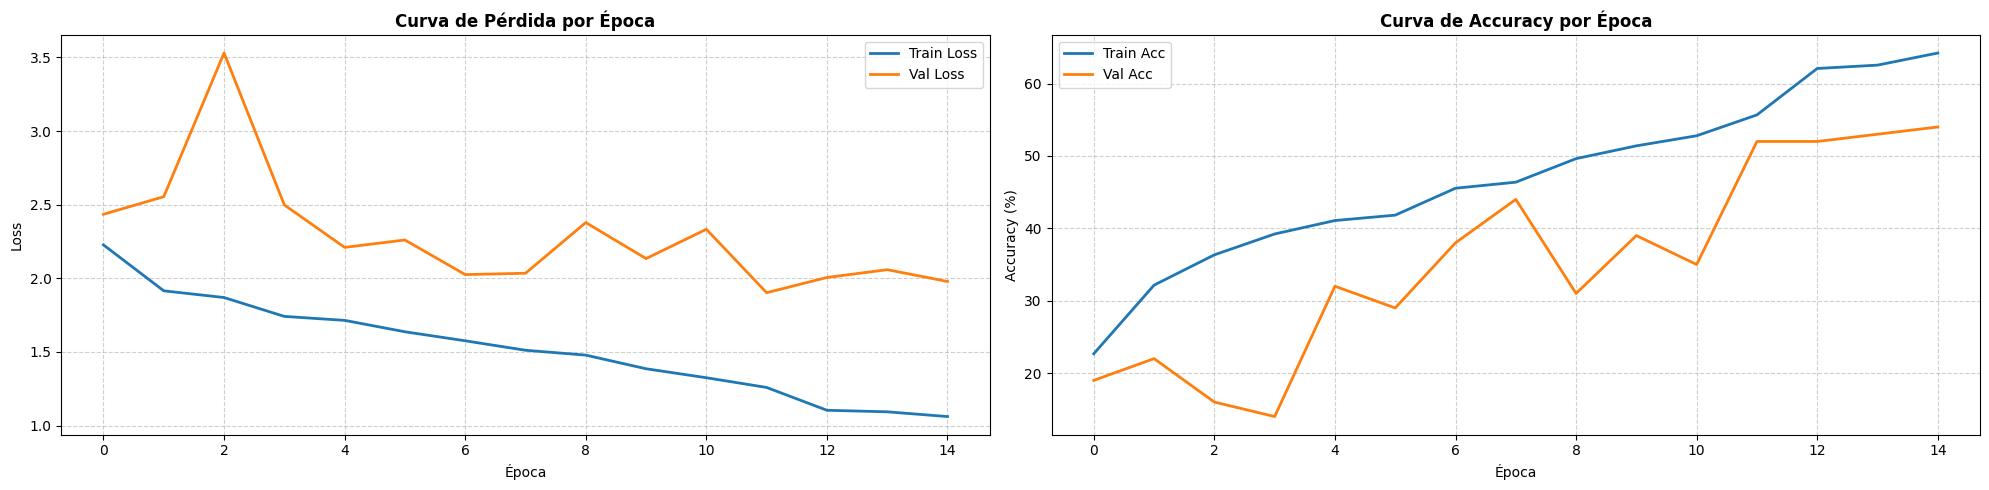

In [51]:
plt.figure(figsize=(20, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(historial_e4['train_loss'], label='Train Loss', color='tab:blue', linewidth=2)
plt.plot(historial_e4['val_loss'], label='Val Loss', color='tab:orange', linewidth=2)
plt.title('Curva de Pérdida por Época', fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Gráfico de Accuracy
plt.subplot(1, 2, 2)
plt.plot([acc * 100 for acc in historial_e4['train_acc']], label='Train Acc', color='tab:blue', linewidth=2)
plt.plot([acc * 100 for acc in historial_e4['val_acc']], label='Val Acc', color='tab:orange', linewidth=2)
plt.title('Curva de Accuracy por Época', fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Al observar los gráficos del mejor experimento obtenido (el Experimento 4), podemos ver que la curva de pérdida del conjunto de entrenamiento (train_loss) va descendiendo de forma progresiva y constante. Por su parte, la pérdida de validación (val_loss) presenta ciertas oscilaciones o picos a lo largo de las 15 épocas.

Por otro lado, en la curva de Accuracy, observamos que el rendimiento en entrenamiento aumenta de manera limpia y sostenida hasta alcanzar el 64.22%, mientras que la curva de validación acompaña esa tendencia alcista con picos intermedios, consolidando su punto óptimo de rendimiento general en un 54%.


La presencia de picos u oscilaciones en las curvas de validación no representa un comportamiento de subajuste ni de inestabilidad algorítmica. Este fenómeno es la respuesta directa de la red ante las técnicas de regularización implementadas. Al entrenar con un pipeline activo de Data Augmentation (que deforma aleatoriamente las fotos en cada lote) y un Dropout de 0.4 (que apaga neuronas al azar), se inyecta un ruido controlado en el proceso de optimización.

#### Matriz de confusión en el conjunto de test

In [ ]:
all_preds = []
all_labels = []

model_e4.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model_e4(X_batch)
        preds = logits.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

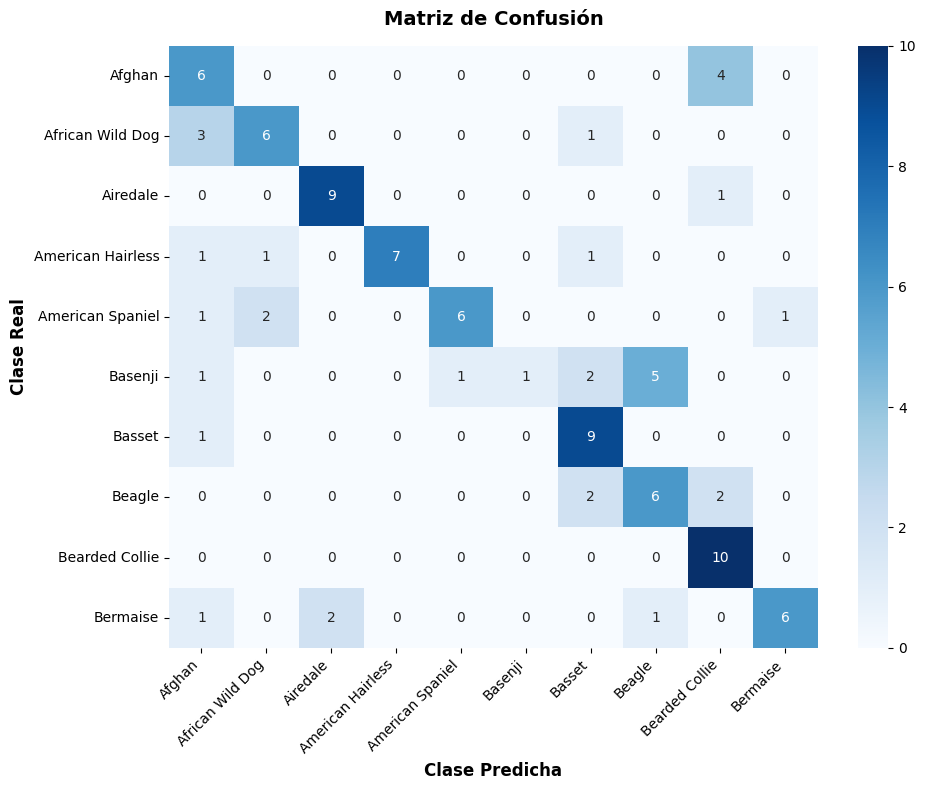

In [57]:
# Calculamos la matriz de confusión 
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, 
    annot=True,                    # Muestra los números adentro de cada cuadrado
    fmt='d',                       # Formato de enteros (diseño limpio sin decimales)
    cmap='Blues', xticklabels=razas_seleccionadas, yticklabels=razas_seleccionadas)

plt.title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Clase Real', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Al analizar la matriz de confusión sobre el conjunto de Test, podemos observar cuáles son las clases que la red logra reconocer con éxito y cuáles presentan los mayores desafíos de clasificación:
- Las razas African Wild Dog (7 aciertos) y Basenji (8 aciertos) presentan los valores más altos sobre la diagonal principal. Esto demuestra que el modelo aprendió a identificar de forma eficiente sus rasgos distintivos únicos.
- La raza Afghan fue la que presentó mayores problemas de detección, registrando apenas 2 aciertos reales. El modelo exhibe una marcada confusión al clasificar 4 muestras de Afghan como Bearded Collie.
- El Beagle obtuvo únicamente 3 aciertos, confundiéndose de manera dispersa con razas como el Basset y el American Spaniel.

Podemos concluir que las razas que más se confunden entre sí son el Beagle con el Basset, y el Afghan con el Bearded Collie, debido a que tienen formas y fisonomías muy parecidas. En el caso de los sabuesos (Beagle y Basset), comparten una paleta de colores tricolor idéntica y orejas largas caídas. Por otro lado, la raza Afghan tiene un pelaje extremadamente largo que cubre casi por completo la silueta y los rasgos faciales del animal. 

#### Ejemplos de predicciones correctas e incorrectas con la imagen (la clase real y la clase predicha)

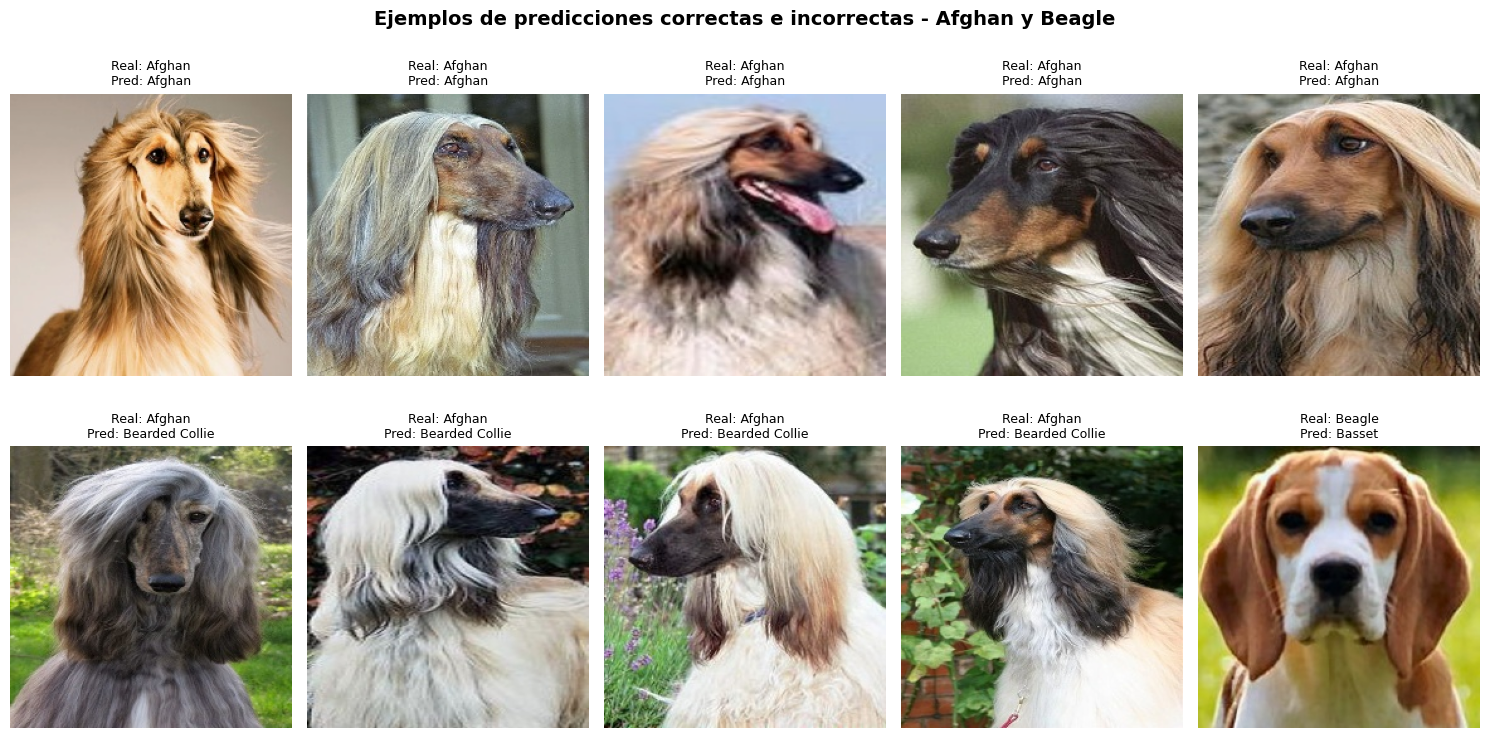

In [72]:
model_e4.eval()

imagenes_ok = []
etiquetas_reales_ok = []
predicciones_modelo_ok = []

imagenes_error = []
etiquetas_reales_error = []
predicciones_modelo_error = []

# Recorremos el dataloader de test
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch_dev = X_batch.to(DEVICE)
        logits = model_e4(X_batch_dev)
        preds = logits.argmax(dim=1).cpu().numpy()
        labels = y_batch.numpy()
        
        for i in range(len(labels)):
            clase_real = razas_seleccionadas[labels[i]]
            clase_pred = razas_seleccionadas[preds[i]]
            
            # Guardamos si el modelo predijo correctamente
            if labels[i] == preds[i]:
                if len(imagenes_ok) < 5:
                    imagenes_ok.append(X_batch[i])
                    etiquetas_reales_ok.append(clase_real)
                    predicciones_modelo_ok.append(clase_pred)
            
            # Guardamos si falló Y la raza real es Afghan o Beagle
            else:
                if clase_real in ['Afghan', 'Beagle']:
                    if len(imagenes_error) < 5:
                        imagenes_error.append(X_batch[i])
                        etiquetas_reales_error.append(clase_real)
                        predicciones_modelo_error.append(clase_pred)
                        
        # Cortamos el bucle cuando ambas listas tengan las 5 muestras 
        if len(imagenes_ok) >= 5 and len(imagenes_error) >= 5:
            break

# Función de desnormalización para recuperar colores reales de ImageNet
def desnormalizar_imagen(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
# Predicciones correctas
for i in range(5):
    ax = axes[0, i]
    if i < len(imagenes_ok):
        ax.imshow(desnormalizar_imagen(imagenes_ok[i]))
        ax.set_title(f"Real: {etiquetas_reales_ok[i]}\nPred: {predicciones_modelo_ok[i]}", fontsize=9)
    ax.axis('off')

# Predicciones incorrectas
for i in range(5):
    ax = axes[1, i]
    if i < len(imagenes_error):
        ax.imshow(desnormalizar_imagen(imagenes_error[i]))
        ax.set_title(f"Real: {etiquetas_reales_error[i]}\nPred: {predicciones_modelo_error[i]}", fontsize=9)
    ax.axis('off')

plt.suptitle("Ejemplos de predicciones correctas e incorrectas - Afghan y Beagle", y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Conclusión
---

El objetivo de este desarrollo fue construir, entrenar y optimizar una red neuronal convolucional (CNN) desde cero para abordar una tarea de clasificación orientada al reconocimiento de 10 razas específicas de perros. A lo largo del laboratorio, se evidenció que la resolución de un problema con un volumen acotado de imágenes requiere un balance milimétrico entre la capacidad de representación geométrica del modelo y las estrategias de regularización.

A partir de una línea base (E1) limitada por el subajuste, la expansión arquitectónica hacia un modelo de 4 bloques convolucionales y más de 1.2 millones de parámetros (E2) demostró la valía de los extractores profundos para aislar características complejas, aunque a costa de un sobreajuste severo. Por su parte, el enfoque estructural residual avanzado (E3), si bien demostró una dinámica de aprendizaje muy limpia y estable, evidenció requerir un horizonte temporal y un costo de cómputo significativamente mayores para converger plenamente bajo condiciones acotadas.

Como conclusión fundamental, el Experimento 4 se consagra como la solución óptima y definitiva del laboratorio, alcanzando una exactitud final del 54% en el conjunto de validación. El éxito de este modelo fue por la integración de un pipeline de Data Augmentation y una tasa de Dropout de 0.4 guiada por optimización bayesiana con Optuna.

Al realizar la matriz de confusión confirmó que las limitaciones remanentes del sistema responden a ambigüedades morfológicas extremas y similitudes cromáticas globales presentes en la naturaleza (pelo largo u orejas caídas de sabuesos). Al carecer del beneficio del aprendizaje por transferencia (Transfer Learning), el balance logrado en el Experimento 4 demuestra que la inyección de ruido controlado y la regularización directa logran forzar a los filtros convolucionales a extraer características invariantes y morfológicas reales en lugar de memorizar píxeles estáticos, consolidando un sistema estable con una alta capacidad de generalización ante datos completamente nuevos.